In [1]:
import numpy as np
import jax.numpy as jnp
from CartPole import *
from Common import *
from Rollout import *
from ModelControl import *

In [2]:
N = 25000
M = 10000
N_test = 10000
data_range = [8,8,jnp.pi,16,20]
X_train, Y_train, axis_names = collect_data(N, data_range)
X_basis = select_basis_centres(X_train, M)
X_test, Y_test, axis_names = collect_data(N_test, data_range)

1749808574
1749809221


In [3]:
save_jnp_array("data_JC1/X_train", X_train)
save_jnp_array("data_JC1/Y_train", Y_train)
save_jnp_array("data_JC1/X_basis", X_basis)
save_jnp_array("data_JC1/X_test", X_test)
save_jnp_array("data_JC1/Y_test", Y_test)

In [4]:
X_train = load_jnp_array("data_JC1/X_train")
X_basis = load_jnp_array("data_JC1/X_basis")
X_test = load_jnp_array("data_JC1/X_test")

In [5]:
Y_train = load_jnp_array("data_JC1/Y_train")
Y_test = load_jnp_array("data_JC1/Y_test")

In [6]:
A_list = []
b_list = []

for j in range(Y_train.shape[1]):
    A_j, b_j = fit_linear(X_train, Y_train[:, j])
    A_list.append(A_j)
    b_list.append(b_j)

A = jnp.vstack(A_list)
b = jnp.array(b_list)

In [7]:
R_train = linear_residuals(X_train, Y_train, A, b)
R_test = linear_residuals(X_test, Y_test, A, b)

In [8]:
save_jnp_array("data_JC1/A", A)
save_jnp_array("data_JC1/b", b)
save_jnp_array("data_JC1/R_train", R_train)
save_jnp_array("data_JC1/R_test", R_test)

In [9]:
A = load_jnp_array("data_JC1/A")
b = load_jnp_array("data_JC1/b")
R_train = load_jnp_array("data_JC1/R_train")
R_test = load_jnp_array("data_JC1/R_test")

In [10]:
sigma_list = []
lam_list = []
alpha_list = []

for j in range(R_train.shape[1]):
    sigma_j, lam_j, alpha_j, _ = fit_hyperparameters(X_train, R_train[:, j], X_basis, X_test, R_test[:, j])
    sigma_list.append(sigma_j)
    lam_list.append([lam_j])
    alpha_list.append(alpha_j)

sigma = jnp.vstack(sigma_list)
lam = jnp.array(lam_list)
alpha = jnp.stack(alpha_list, axis=1)

In [11]:
save_jnp_array("data_JC1/sigma", sigma)
save_jnp_array("data_JC1/lam", lam)
save_jnp_array("data_JC1/alpha", alpha)

In [12]:
sigma = load_jnp_array("data_JC1/sigma")
lam = load_jnp_array("data_JC1/lam")
alpha = load_jnp_array("data_JC1/alpha")

In [13]:
MSE_vector = jnp.array([
    non_linear_MSE(X_test, R_test[:, j], X_basis, alpha[:, j], sigma[j]) 
    for j in range(jnp.shape(Y_test)[1])
])
print(MSE_vector)
print(jnp.log(jnp.prod(MSE_vector)))

[9.7751486e-05 2.2277340e-02 7.7942008e-04 3.1820747e-01]
-21.33928


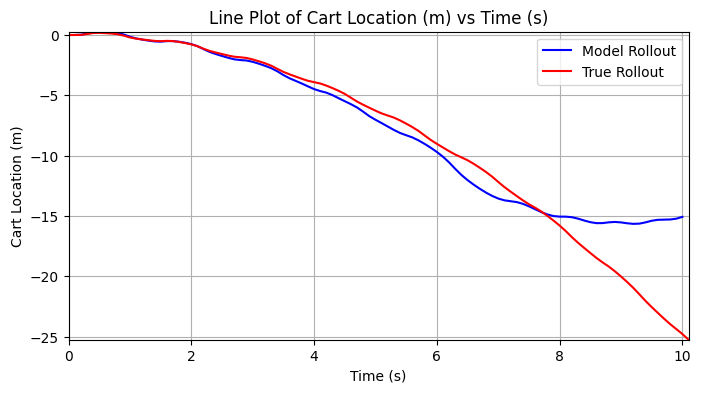

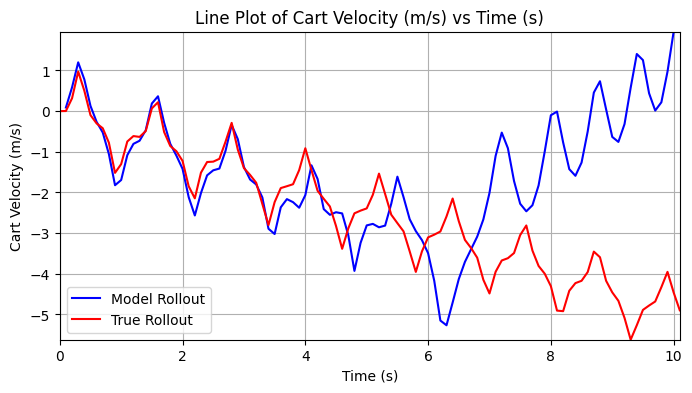

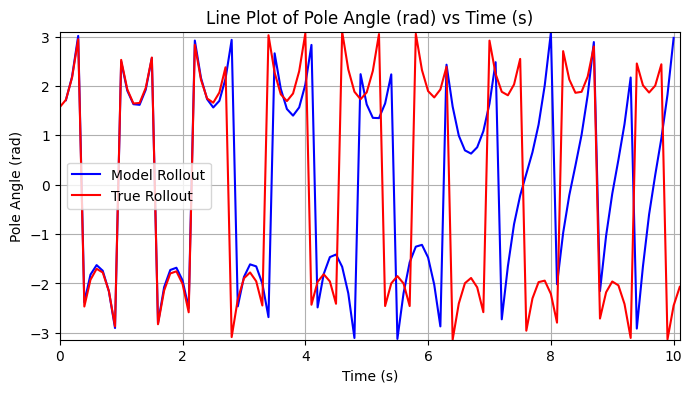

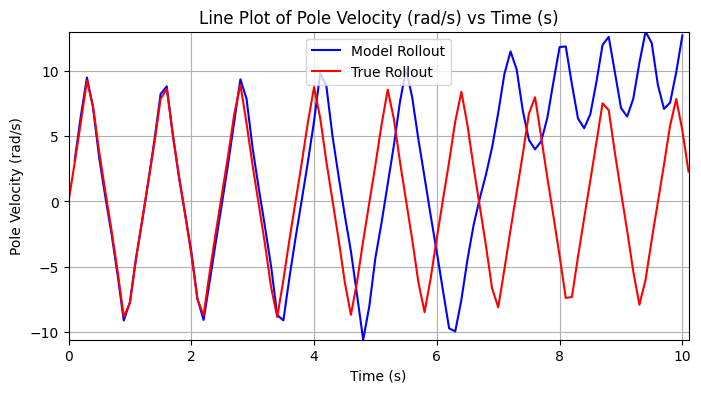

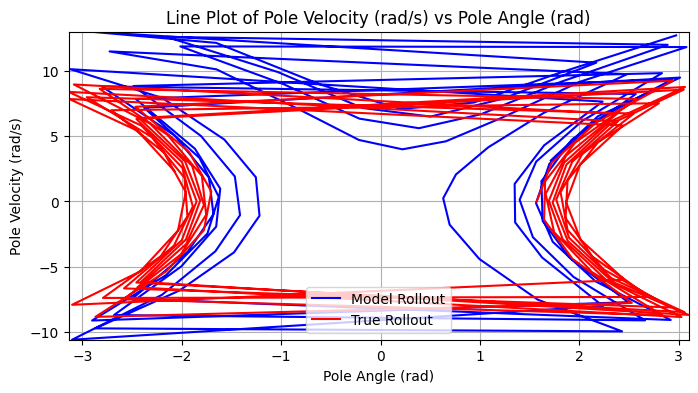

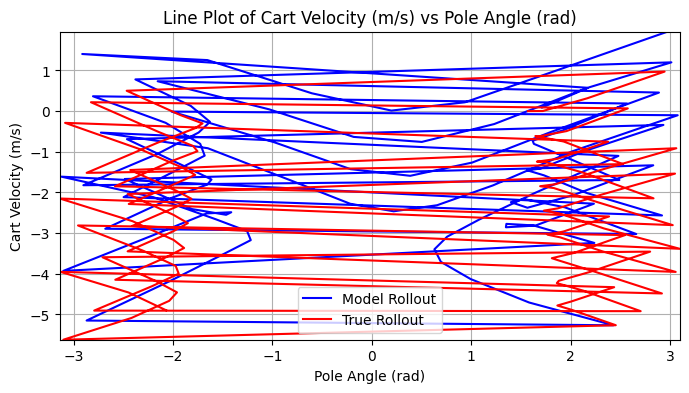

In [35]:
initial_state = [0.0, 0.0, np.pi/2, 0.0]
action = -0.5

state_array = joint_rollout(initial_state, action, A, b, X_basis, alpha, sigma, 10)
true_state_array, _ = rollout_action(initial_state, action, 10)

axis_names_1 = ['Cart Location (m)','Cart Velocity (m/s)','Pole Angle (rad)','Pole Velocity (rad/s)', 'Force (N)', 'Time (s)']
plot_model_graph(state_array, true_state_array, -1, 0, axis_names_1)
plot_model_graph(state_array, true_state_array, -1, 1, axis_names_1)
plot_model_graph(state_array, true_state_array, -1, 2, axis_names_1)
plot_model_graph(state_array, true_state_array, -1, 3, axis_names_1)
plot_model_graph(state_array, true_state_array, 2, 3, axis_names_1)
plot_model_graph(state_array, true_state_array, 2, 1, axis_names_1)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=58725ef8-9a26-4e31-9e4c-5d3613b1a28f' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>